In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np 
import pandas as pd 
import cartopy.crs as ccrs
import cmocean
import seaborn as sns
import statsmodels.api as sm
from scipy.stats import pearsonr 
from scipy.stats import shapiro 
from scipy.stats import linregress 
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
from OceanDataStore import OceanDataCatalog 
from nemo_cookbook import NEMODataTree  
from matplotlib.patches import Rectangle


In [2]:
def select_by_latlon(ds, lat_target, lon_target):
    lat = ds['gphit'].values
    lon = ds['glamt'].values
    distance = np.sqrt((lat - lat_target)**2 + (lon - lon_target)**2)
    y_idx, x_idx = np.unravel_index(np.argmin(distance), distance.shape)
    print('x index =', x_idx)
    print('y index =', y_idx)
    return ds.isel(y=y_idx, x=x_idx)

In [3]:
salinity = xr.open_dataset('salinity_ts_0.25.nc')['sos_abs']
salinity['time_counter'] = salinity['time_counter'].dt.year
ice_years = (xr.open_dataset('../Hillary/Ice_cover/Ice_edge.nc'))['soicecov']

In [ ]:
ny, nx = salinity.sizes['j'], salinity.sizes['i']
trend_data = np.full((ny, nx), np.nan, dtype = np.float32)
pval_data = np.full((ny, nx), np.nan, dtype = np.float32) 

for j_idx in range (ny):
    for i_idx in range (nx):
        point = salinity.isel(j=j_idx, i=i_idx)
        if np.isnan(point).all():
            continue
        Y = point.values
        X = sm.add_constant(point['time_counter'].values)
        model = sm.GLSAR(Y, X, 1)
        results = model.iterative_fit(maxiter=50)
        trend_data[j_idx, i_idx] = results.params[1] 
        pval_data[j_idx, i_idx] = results.pvalues[1]
    print(j_idx)

trend_da = xr.DataArray(data = trend_data, dims=['j', 'i'], 
        coords={ 'j': salinity['j'],
        'i': salinity['i'],
        'gphit': (('j', 'i'), salinity['gphit'].values),
        'glamt': (('j', 'i'), salinity['glamt'].values)}, name='trend',
        attrs={'description': 'Linear trend over time of sea-surface salinity'})

pval_da = xr.DataArray(data = pval_data, dims=['j', 'i'], 
        coords={ 'j': salinity['j'],
        'i': salinity['i'],
        'gphit': (('j', 'i'), salinity['gphit'].values),
        'glamt': (('j', 'i'), salinity['glamt'].values)}, name='trend',
        attrs={'description': 'P-value for linear trend over time of sea-surface salinity'})

In [5]:
## Save DataArrays

trend_da.to_netcdf('salinity_trends_0.25.nc')
pval_da.to_netcdf('salinity_trends_pval_0.25.nc')

In [4]:
## Start from here in future 

trend_da = xr.open_dataset('salinity_trends_0.25.nc')['trend']
pval_da = xr.open_dataset('salinity_trends_pval_0.25.nc')['trend']

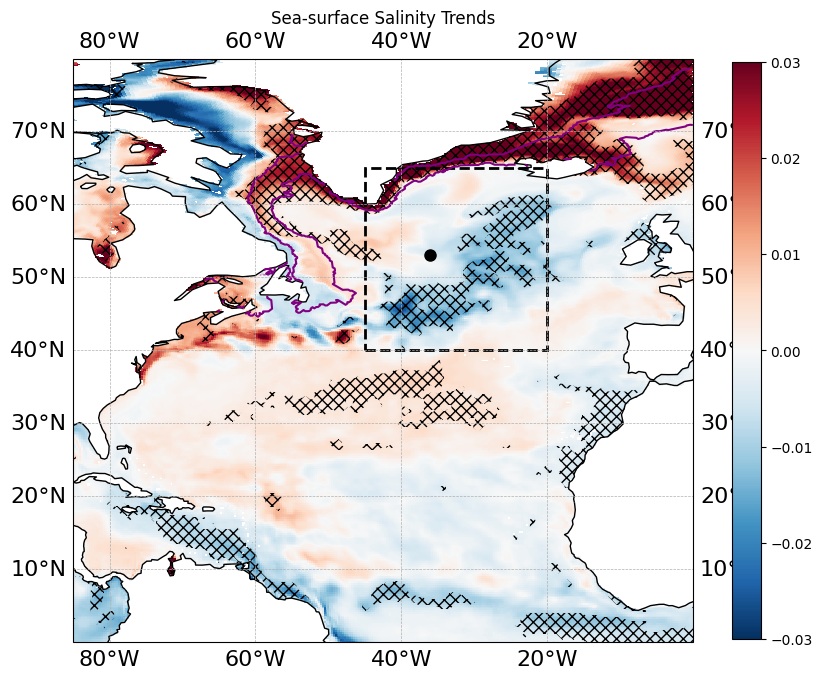

In [5]:
## Hatched Plot 

sig_mask = pval_da < 0.05

fig, ax = plt.subplots(figsize = (10,25), subplot_kw={'projection': ccrs.PlateCarree()})
im = ax.pcolormesh(trend_da['glamt'], trend_da['gphit'], trend_da, cmap='RdBu_r', transform=ccrs.PlateCarree(), vmin = -0.03, vmax = 0.03)  
ax.set_extent([-85.0, 0.0, 0.0, 80.0], crs=ccrs.PlateCarree())
ax.contour(ice_years['glamt'], ice_years['gphit'], ice_years, levels=[0.001, 34.999],colors='purple',transform=ccrs.PlateCarree())
cl = ax.coastlines()
gl = ax.gridlines(draw_labels=True, linewidth=0.5, linestyle='--')
gl.xlabel_style = {'size': 16}
gl.ylabel_style = {'size': 16}
significance = ax.contourf(sig_mask['glamt'], sig_mask['gphit'], sig_mask, levels=[0.5, 1.0], colors='none', hatches=['xxx'], transform=ccrs.PlateCarree())
title = ax.set_title('Sea-surface Salinity Trends')
box = Rectangle((-45, 40), 25, 25, linewidth=2, edgecolor='black', facecolor='none', linestyle='--', transform=ccrs.PlateCarree())
ax.add_patch(box)
ax.plot(-36, 53, 'ko', markersize=8, transform=ccrs.PlateCarree())
plt.colorbar(im, ax=ax, shrink = 0.3)
plt.savefig('salinity_trends.png')


In [ ]:
## Consider pre-2015 trends 

subsample = salinity.sel(time_counter = slice(1990, 2014))

ny, nx = subsample.sizes['j'], subsample.sizes['i']
trend_data = np.full((ny, nx), np.nan, dtype = np.float32)
pval_data = np.full((ny, nx), np.nan, dtype = np.float32) 

for j_idx in range (ny):
    for i_idx in range (nx):
        point = subsample.isel(j=j_idx, i=i_idx)
        if np.isnan(point).all():
            continue
        Y = point.values
        X = sm.add_constant(point['time_counter'].values)
        model = sm.GLSAR(Y, X, 1)
        results = model.iterative_fit(maxiter=10)
        trend_data[j_idx, i_idx] = results.params[1] 
        pval_data[j_idx, i_idx] = results.pvalues[1]
    print(j_idx)


In [10]:
trend_da = xr.DataArray(data = trend_data, dims=['j', 'i'], 
        coords={ 'j': subsample['j'],
        'i': subsample['i'],
        'gphit': (('j', 'i'), subsample['gphit'].values),
        'glamt': (('j', 'i'), subsample['glamt'].values)}, name='trend',
        attrs={'description': 'Linear trend over time of sea-surface salinity'})

pval_da = xr.DataArray(data = pval_data, dims=['j', 'i'], 
        coords={ 'j': subsample['j'],
        'i': subsample['i'],
        'gphit': (('j', 'i'), subsample['gphit'].values),
        'glamt': (('j', 'i'), subsample['glamt'].values)}, name='trend',
        attrs={'description': 'P-value for linear trend over time of sea-surface salinity'})

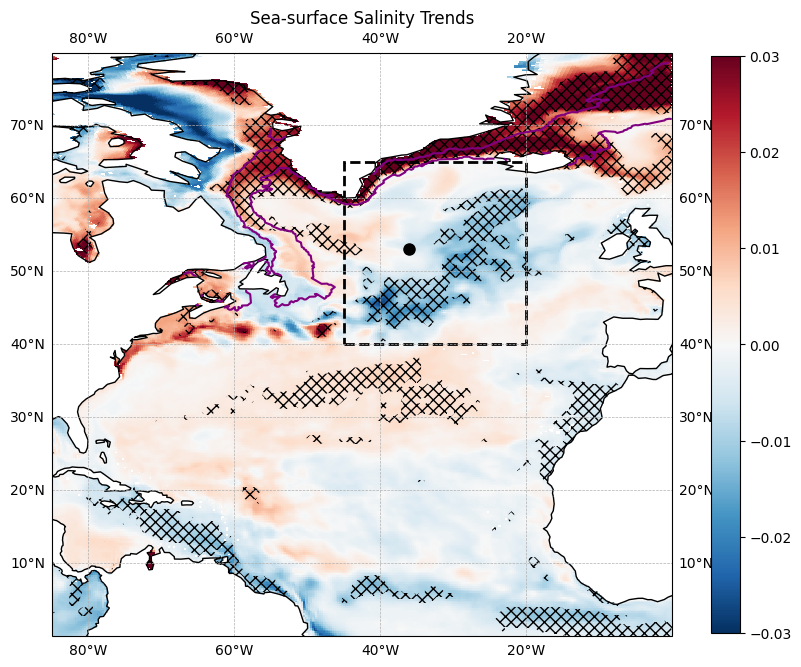

In [8]:
## Hatched Plot 

sig_mask = pval_da < 0.05

fig, ax = plt.subplots(figsize = (10,25), subplot_kw={'projection': ccrs.PlateCarree()})
im = ax.pcolormesh(trend_da['glamt'], trend_da['gphit'], trend_da, cmap='RdBu_r', transform=ccrs.PlateCarree(), vmin = -0.03, vmax = 0.03)  
ax.set_extent([-85.0, 0.0, 0.0, 80.0], crs=ccrs.PlateCarree())
cl = ax.coastlines()
gl = ax.gridlines(draw_labels=True, linewidth=0.5, linestyle='--')
ax.contour(ice_years['glamt'], ice_years['gphit'], ice_years, levels=[0.001, 34.999],colors='purple',transform=ccrs.PlateCarree())
significance = ax.contourf(sig_mask['glamt'], sig_mask['gphit'], sig_mask, levels=[0.5, 1.0], colors='none', hatches=['xxx'], transform=ccrs.PlateCarree())
title = ax.set_title('Sea-surface Salinity Trends')
box = Rectangle((-45, 40), 25, 25, linewidth=2, edgecolor='black', facecolor='none', linestyle='--', transform=ccrs.PlateCarree())
ax.add_patch(box)
ax.plot(-36, 53, 'ko', markersize=8, transform=ccrs.PlateCarree())
plt.colorbar(im, ax=ax, shrink = 0.3)


In [ ]:
## 2015-2024

subsample = salinity.sel(time_counter = slice(2015, 2024))

ny, nx = subsample.sizes['j'], subsample.sizes['i']
trend_data = np.full((ny, nx), np.nan, dtype = np.float32)
pval_data = np.full((ny, nx), np.nan, dtype = np.float32) 

for j_idx in range (ny):
    for i_idx in range (nx):
        point = subsample.isel(j=j_idx, i=i_idx)
        if np.isnan(point).all():
            continue
        Y = point.values
        X = sm.add_constant(point['time_counter'].values)
        model = sm.GLSAR(Y, X, 1)
        results = model.iterative_fit(maxiter=10)
        trend_data[j_idx, i_idx] = results.params[1] 
        pval_data[j_idx, i_idx] = results.pvalues[1]
    print(j_idx)


In [13]:
trend_da = xr.DataArray(data = trend_data, dims=['j', 'i'], 
        coords={ 'j': subsample['j'],
        'i': subsample['i'],
        'gphit': (('j', 'i'), subsample['gphit'].values),
        'glamt': (('j', 'i'), subsample['glamt'].values)}, name='trend',
        attrs={'description': 'Linear trend over time of sea-surface salinity'})

pval_da = xr.DataArray(data = pval_data, dims=['j', 'i'], 
        coords={ 'j': subsample['j'],
        'i': subsample['i'],
        'gphit': (('j', 'i'), subsample['gphit'].values),
        'glamt': (('j', 'i'), subsample['glamt'].values)}, name='trend',
        attrs={'description': 'P-value for linear trend over time of sea-surface salinity'})

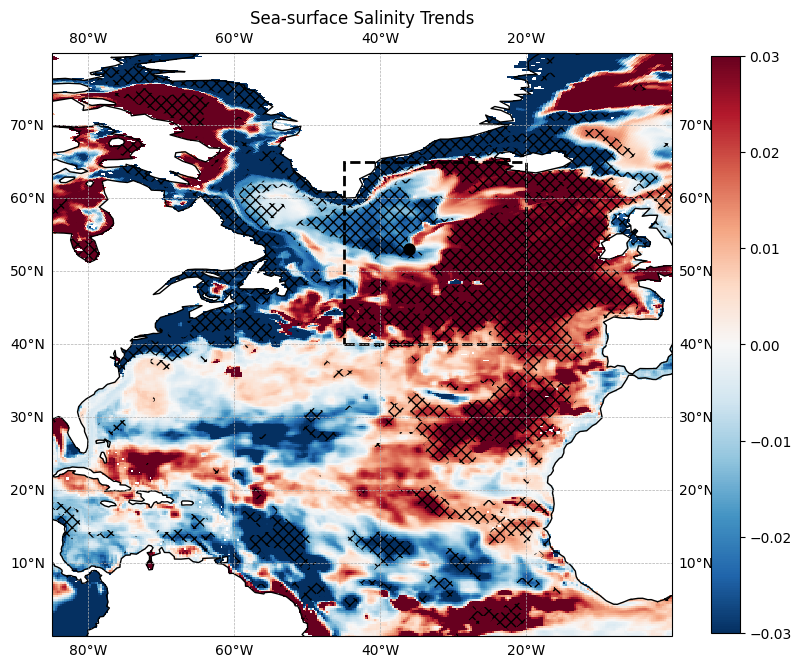

In [14]:
## Hatched Plot 

sig_mask = pval_da < 0.05

fig, ax = plt.subplots(figsize = (10,25), subplot_kw={'projection': ccrs.PlateCarree()})
im = ax.pcolormesh(trend_da['glamt'], trend_da['gphit'], trend_da, cmap='RdBu_r', transform=ccrs.PlateCarree(), vmin = -0.03, vmax = 0.03)  
ax.set_extent([-85.0, 0.0, 0.0, 80.0], crs=ccrs.PlateCarree())
cl = ax.coastlines()
gl = ax.gridlines(draw_labels=True, linewidth=0.5, linestyle='--')
significance = ax.contourf(sig_mask['glamt'], sig_mask['gphit'], sig_mask, levels=[0.5, 1.0], colors='none', hatches=['xxx'], transform=ccrs.PlateCarree())
title = ax.set_title('Sea-surface Salinity Trends')
box = Rectangle((-45, 40), 25, 25, linewidth=2, edgecolor='black', facecolor='none', linestyle='--', transform=ccrs.PlateCarree())
ax.add_patch(box)
ax.plot(-36, 53, 'ko', markersize=8, transform=ccrs.PlateCarree())
plt.colorbar(im, ax=ax, shrink = 0.3)
